# Part 1 Images

## Imports

In [1]:
from manim import *
from manim_helpers import *

## Scenes

### Defining Natural Numbers

#### Various Examples of 3

Manim Community v0.18.1

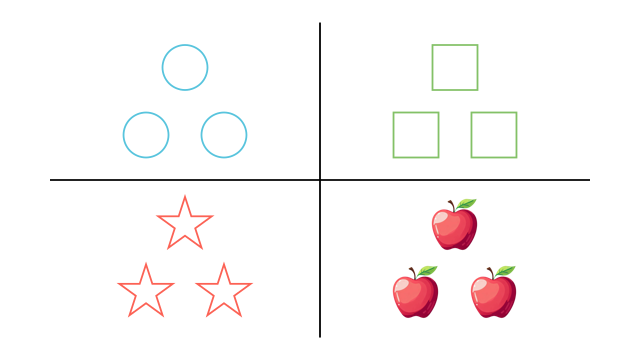

In [2]:
%%manim --output_file 1_constructing-numbers_three.png ThreeDiagram

CIRCLE_WIDTH = 1
CIRCLE_COLOUR = BLUE

SQUARE_WIDTH = 1
SQUARE_COLOUR = GREEN

STAR_WIDTH = 1.25
STAR_COLOUR = RED


class ThreeDiagram(Scene):
    def construct(self):
        # Define quadrants
        horizontal_line = Line(LEFT*6, RIGHT*6, color=BLACK)
        vertical_line = Line(UP*3.5, DOWN*3.5, color=BLACK)
        self.add(horizontal_line, vertical_line)

        # Create the three circles
        circles = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR) for i in range(3)]
        )
        arrange_circular(*circles)
        circles.shift(UP*1.5 + LEFT*3)
        self.add(circles)

        # Create the three squares
        squares = VGroup(
            *[Square(side_length=SQUARE_WIDTH, color=SQUARE_COLOUR) for i in range(3)]
        )
        arrange_circular(*squares)
        squares.shift(UP*1.5 + RIGHT*3)
        self.add(squares)

        # Create the three stars
        stars = VGroup(
            *[Star(outer_radius=STAR_WIDTH/2, color=STAR_COLOUR) for i in range(3)]
        )
        arrange_circular(*stars)
        stars.shift(DOWN*2 + LEFT*3)
        self.add(stars)

        # Create the three apples
        apples = Group(
            *[ImageMobject("images/Red_Apple_Icon.png").scale(0.25) for i in range(3)]
        )
        arrange_circular(*apples)
        apples.shift(DOWN*2 + RIGHT*3)
        self.add(apples)

#### Counting Down To Zero

Manim Community v0.18.1

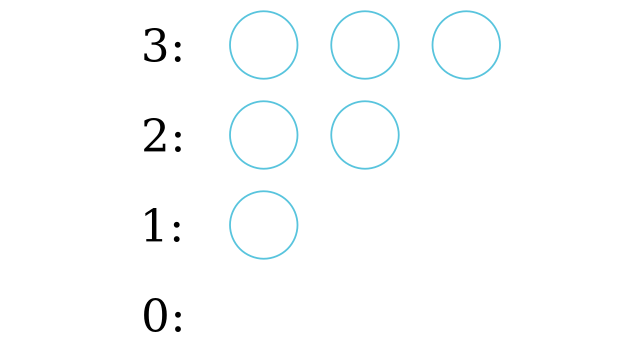

In [3]:
%%manim --output_file 1_constructing-numbers_counting.png CountingDiagram

FONT_SIZE = 72

CIRCLE_WIDTH = 1.5
CIRCLE_COLOUR = BLUE

class CountingDiagram(Scene):
    def construct(self):
        # Three
        three_label = Text("3:", font_size=FONT_SIZE, color=BLACK)
        three_elements = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*(i+1)*1.5*CIRCLE_WIDTH) for i in range(3)]
        )

        three_group = Group(three_label, three_elements)
        three_group.shift(3.5*LEFT)  # To align the label correctly
        three_group.shift(UP*3)
        self.add(three_group)

        # Two
        two_label = Text("2:", font_size=FONT_SIZE, color=BLACK)
        two_elements = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*(i+1)*1.5*CIRCLE_WIDTH) for i in range(2)]
        )

        two_group = Group(two_label, two_elements)
        two_group.shift(3.5*LEFT)  # To align the label correctly
        two_group.shift(UP*1)
        self.add(two_group)

        # One
        one_label = Text("1:", font_size=FONT_SIZE, color=BLACK)
        one_elements = VGroup(
            Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*1.5*CIRCLE_WIDTH)
        )

        one_group = Group(one_label, one_elements)
        one_group.shift(3.5*LEFT)  # To align the label correctly
        one_group.shift(DOWN*1)
        self.add(one_group)

        # Zero
        zero_label = Text("0:", font_size=FONT_SIZE, color=BLACK)
        zero_label.shift(3.5*LEFT)  # To align the label correctly
        zero_label.shift(DOWN*3)
        self.add(zero_label)

#### The First 5 Counter Sets

Manim Community v0.18.1

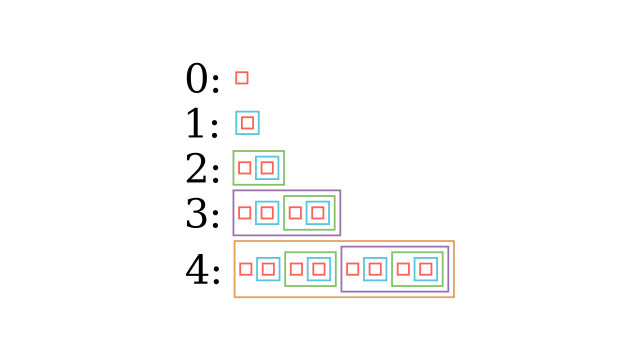

In [4]:
%%manim --output_file 1_constructing-numbers_counter-sets.png CounterSetsDiagram

FONT_SIZE = 64

ZERO_BOX_WIDTH = 0.25

BUFF = 0.125
COLOURS = [RED, BLUE, GREEN, PURPLE, GOLD_D, TEAL_C]

def generate_set(scene: Scene, n: int, is_last: bool = True) -> Mobject:
    if n == 0:
        return Square(side_length=ZERO_BOX_WIDTH, color=COLOURS[0])
    
    sets = []
    for i in range(n):
        sets.append(generate_set(scene, i, is_last=False))
    
    sets_group = VGroup(*sets)
    current_shift = BUFF
    for s in sets:
        s.shift(current_shift * RIGHT)
        current_shift += s.width + BUFF

    surround = SurroundingRectangle(sets_group, buff=BUFF, color=COLOURS[n%len(COLOURS)])
    scene.add(sets_group)

    the_set = VGroup(sets_group, surround)

    if is_last:
        the_set = the_set.center()
    return the_set


class CounterSetsDiagram(Scene):
    def construct(self):
        # Zero
        zero_label = Text("0:", font_size=FONT_SIZE, color=BLACK)
        zero_set = generate_set(self, 0).shift(0.875*RIGHT)

        zero_group = Group(zero_label, zero_set)
        zero_group.shift(3.5*LEFT)  # To align the label correctly
        zero_group.shift(UP*2)

        # One
        one_label = Text("1:", font_size=FONT_SIZE, color=BLACK)
        one_set = generate_set(self, 1).shift(RIGHT)

        one_group = Group(one_label, one_set)
        one_group.shift(3.5*LEFT)  # To align the label correctly
        one_group.shift(UP*1)

        # Two
        two_label = Text("2:", font_size=FONT_SIZE, color=BLACK)
        two_set = generate_set(self, 2).shift(1.25*RIGHT)

        two_group = Group(two_label, two_set)
        two_group.shift(3.5*LEFT)  # To align the label correctly
        two_group

        # Three
        three_label = Text("3:", font_size=FONT_SIZE, color=BLACK)
        three_set = generate_set(self, 3).shift(1.875*RIGHT)

        three_group = Group(three_label, three_set)
        three_group.shift(3.5*LEFT)  # To align the label correctly
        three_group.shift(DOWN*1)

        # Four
        four_label = Text("4:", font_size=FONT_SIZE, color=BLACK)
        four_set = generate_set(self, 4).shift(3.15*RIGHT)

        four_group = Group(four_label, four_set)
        four_group.shift(3.5*LEFT)  # To align the label correctly
        four_group.shift(DOWN*2.25)

        # Add all
        all_groups = Group(
            zero_group, one_group, two_group, three_group, four_group
        )
        all_groups.center()
        self.add(all_groups)

### Relations I

#### The "lived in" Relation

Manim Community v0.18.1

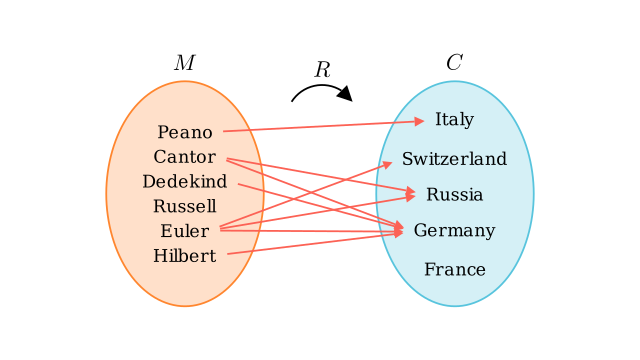

In [5]:
%%manim --output_file 1_relations-1_lived-in-relation.png RelationDiagram

M_FONT_SIZE = 28
C_FONT_SIZE = 28

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class RelationDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_m = Ellipse(width=3.5, height=5, color=ORANGE)
        ellipse_m.set_fill(ORANGE, opacity=0.25)
        ellipse_m.shift(LEFT * 3)
        
        ellipse_c = Ellipse(width=3.5, height=5, color=BLUE)
        ellipse_c.set_fill(BLUE, opacity=0.25)
        ellipse_c.shift(RIGHT * 3)
        
        # Create labels for the ellipses
        label_m = MathTex("M", color=BLACK).next_to(ellipse_m, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)
        
        # Create elements for sets
        elements_m = ["Peano", "Cantor", "Dedekind", "Russell", "Euler", "Hilbert"]
        elements_c = ["Italy", "Switzerland", "Russia", "Germany", "France"]

        elements_m = [Text(m, font_size=M_FONT_SIZE, color=BLACK) for m in elements_m]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_m = VGroup(*elements_m).arrange(DOWN, buff=0.25).move_to(ellipse_m)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.5).move_to(ellipse_c)
        
        # Create arrows
        arrow_links = [
            (0, 0),  # Peano-Italy
            (1, 2),  # Cantor-Russia  
            (1, 3),  # Cantor-Germany
            (2, 3),  # Dedekind-Germany
            (4, 1),  # Euler-Switzerland
            (4, 2),  # Euler-Russia
            (4, 3),  # Euler-Germany
            (5, 3)   # Hilbert-Germany
        ]
        arrows = [
            Arrow(
                elements_m[i].get_right(),
                elements_c[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add relation label above the arrows
        relation_label = MathTex("R", color=BLACK).next_to(arrows, 3.5*UP)
        relation_label.add(
            CurvedArrow(
                relation_label.get_left() + LEFT * 0.5,
                relation_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_m, ellipse_c, label_m, label_c, elements_m, elements_c, arrows, relation_label)
        group.center()
        self.add(group)

#### The "is less than" Relation

Manim Community v0.18.1

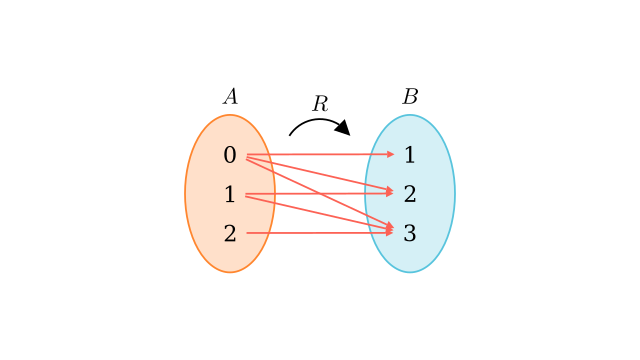

In [6]:
%%manim --output_file 1_relations-1_less-than-relation.png RelationDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class RelationDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=3.5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=3.5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2"]
        elements_b = ["1", "2", "3"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0, 0),
            (0, 1),
            (0, 2),
            (1, 1),
            (1, 2),
            (2, 2)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add relation label above the arrows
        relation_label = MathTex("R", color=BLACK).next_to(arrows, 3.5*UP)
        relation_label.add(
            CurvedArrow(
                relation_label.get_left() + LEFT * 0.5,
                relation_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, relation_label)
        group.center()
        self.add(group)

#### Relation on a Set

The standard arrow diagram.

Manim Community v0.18.1

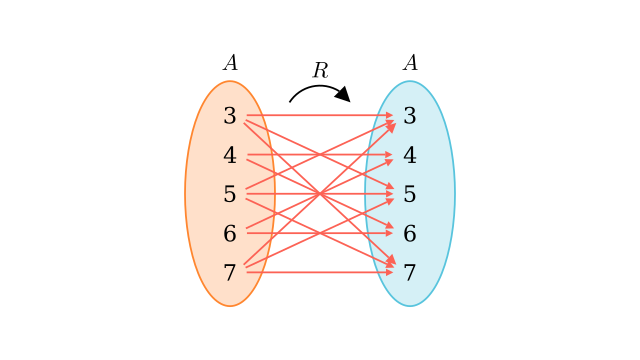

In [7]:
%%manim --output_file 1_relations-1_relation-on-a-set_arrow-diagram.png RelationDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class RelationDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("A", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements = ["3", "4", "5", "6", "7"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0, 0),
            (0, 2),
            (0, 4),
            (1, 1),
            (1, 3),
            (2, 0),
            (2, 2),
            (2, 4),
            (3, 1),
            (3, 3),
            (4, 0),
            (4, 2),
            (4, 4)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add relation label above the arrows
        relation_label = MathTex("R", color=BLACK).next_to(arrows, 3*UP)
        relation_label.add(
            CurvedArrow(
                relation_label.get_left() + LEFT * 0.5,
                relation_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, relation_label)
        group.center()
        self.add(group)

The directed graph variant.

Manim Community v0.18.1

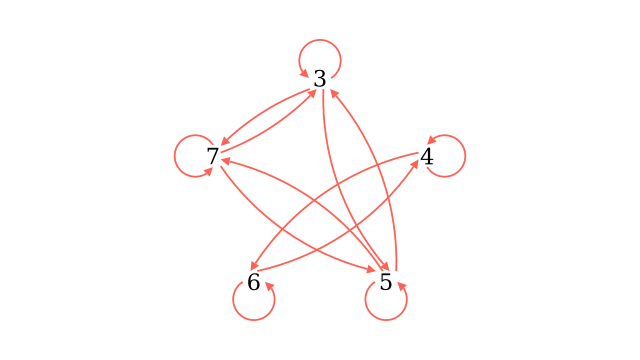

In [8]:
%%manim --output_file 1_relations-1_relation-on-a-set_directed-graph.png RelationDiagram

FONT_SIZE = 36

RADIUS = 2.5  # Radius of pentagon

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["3", "4", "5", "6", "7"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_top() + ELEMENT_POS_SHIFT*UP,
            4: elements[4].get_right() + ELEMENT_POS_SHIFT*RIGHT
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[4].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 2): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*RIGHT),
            (0, 4): ((1.5*ARROW_START_SHIFT)*LEFT, (1.5*ARROW_START_SHIFT)*UP),
            (1, 3): ((0.5*ARROW_START_SHIFT)*UP, (0.5*ARROW_START_SHIFT)*LEFT),
            (2, 0): ((1.5*ARROW_START_SHIFT)*RIGHT, (1.5*ARROW_START_SHIFT)*RIGHT),
            (2, 4): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*DOWN),
            (3, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*DOWN),
            (4, 0): ((0.5*ARROW_START_SHIFT)*UP, (0.5*ARROW_START_SHIFT)*LEFT),
            (4, 2): ((1.5*ARROW_START_SHIFT)*DOWN, (1.5*ARROW_START_SHIFT)*LEFT)
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 6
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

#### The Inverse of the "is less than" Relation

Manim Community v0.18.1

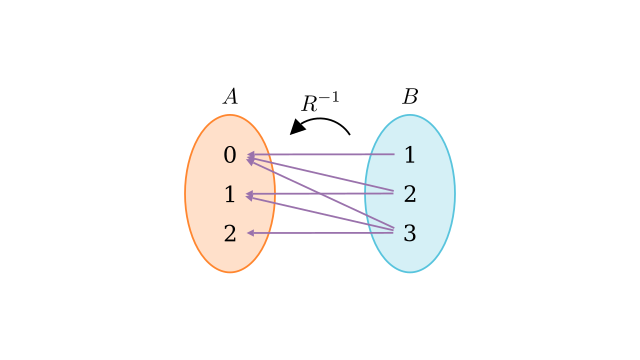

In [28]:
%%manim --output_file 1_relations-1_less-than-relation-inverse.png RelationDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class RelationDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=3.5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=3.5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2"]
        elements_b = ["1", "2", "3"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0, 0),
            (0, 1),
            (0, 2),
            (1, 1),
            (1, 2),
            (2, 2)
        ]
        arrows = [
            Arrow(
                elements_b[j].get_left(),
                elements_a[i].get_right(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=PURPLE
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add relation label above the arrows
        relation_label = MathTex("R^{-1}", color=BLACK).next_to(arrows, 3.5*UP)
        relation_label.add(
            CurvedArrow(
                relation_label.get_right() + RIGHT * 0.25,
                relation_label.get_left() + LEFT * 0.25,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).shift(DOWN * 0.75)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, relation_label)
        group.center()
        self.add(group)